In [ ]:
!pip install meteostat --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from meteostat import Point, Daily

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

pd.set_option("display.max_columns", 60)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [ ]:
# --- NYC Yellow Taxi data: January 2020 ---
TAXI_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-01.parquet"

print("Loading taxi data from:", TAXI_URL)
taxi_df = pd.read_parquet(TAXI_URL)
print("Taxi shape:", taxi_df.shape)
display(taxi_df.head())

# --- NYC Weather data via Meteostat API (Wall Street) ---
nyc_point = Point(40.7060, -74.0086)

start = datetime(2020, 1, 1)
end   = datetime(2020, 1, 31)

weather_jan = Daily(nyc_point, start=start, end=end).fetch()
weather_df = weather_jan.reset_index().rename(columns={"time": "date"})

print("Weather (Jan 2020) shape:", weather_df.shape)
display(weather_df.head())


Loading taxi data from: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-01.parquet
Taxi shape: (6405008, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,None
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,None
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,None
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,None
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,None


Weather (Jan 2020) shape: (31, 11)


,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2020-01-01,3.6,1.7,5.0,0.0,0.0,<NA>,17.3,<NA>,1008.2,<NA>
1,2020-01-02,4.7,0.6,8.9,0.0,0.0,<NA>,12.4,<NA>,1013.9,<NA>
2,2020-01-03,7.6,6.7,8.3,2.8,0.0,<NA>,8.4,<NA>,1010.2,<NA>
3,2020-01-04,8.2,6.7,9.4,5.3,0.0,<NA>,5.7,<NA>,1003.7,<NA>
4,2020-01-05,4.6,2.8,7.2,0.0,0.0,<NA>,8.2,<NA>,1010.1,<NA>


In [ ]:
df = taxi_df.copy()

# Ensure datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Trip duration in minutes (target)
df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60.0

# Basic trip filters
df = df[
    (df["trip_duration_min"] > 1) &
    (df["trip_duration_min"] <= 180) &
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 50)
].copy()

df = df.dropna(subset=["trip_distance", "trip_duration_min"])

# Time features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday
df["is_weekend"] = df["pickup_weekday"].isin([5, 6]).astype(int)
df["is_rush_hour"] = df["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

# For merging with weather
df["pickup_date"] = df["tpep_pickup_datetime"].dt.normalize()

print("Cleaned taxi shape:", df.shape)
display(df.head())


Cleaned taxi shape: (6294171, 25)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_min,pickup_hour,pickup_weekday,is_weekend,is_rush_hour,pickup_date
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,None,4.800000,0,2,0,0,2020-01-01
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,None,7.416667,0,2,0,0,2020-01-01
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,None,6.183333,0,2,0,0,2020-01-01
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,None,4.850000,0,2,0,0,2020-01-01
9,1,2020-01-01 00:29:01,2020-01-01 00:40:28,2.0,0.7,1.0,N,246,48,1,8.0,3.0,0.5,2.35,0.0,0.3,14.15,2.5,None,11.450000,0,2,0,0,2020-01-01


In [ ]:
w = weather_df.copy()
w["date"] = pd.to_datetime(w["date"])
w = w.sort_values("date").copy()
w = w.interpolate(method="linear", limit_direction="both").copy()

merged_df = df.merge(
    w,
    left_on="pickup_date",
    right_on="date",
    how="left"
).copy()

merged_df.drop(columns=["date"], inplace=True, errors="ignore")

print("Merged_df shape:", merged_df.shape)
display(merged_df.head())


Merged_df shape: (6294171, 35)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_min,pickup_hour,pickup_weekday,is_weekend,is_rush_hour,pickup_date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,None,4.800000,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,<NA>,17.3,<NA>,1008.2,<NA>
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,None,7.416667,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,<NA>,17.3,<NA>,1008.2,<NA>
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,None,6.183333,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,<NA>,17.3,<NA>,1008.2,<NA>
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,None,4.850000,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,<NA>,17.3,<NA>,1008.2,<NA>
4,1,2020-01-01 00:29:01,2020-01-01 00:40:28,2.0,0.7,1.0,N,246,48,1,8.0,3.0,0.5,2.35,0.0,0.3,14.15,2.5,None,11.450000,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,<NA>,17.3,<NA>,1008.2,<NA>


In [ ]:
# avg_mph: safe computation
avg_mph = merged_df["trip_distance"] / (merged_df["trip_duration_min"] / 60.0)
avg_mph = avg_mph.replace([np.inf, -np.inf], np.nan)

if avg_mph.notna().any():
    avg_mph = avg_mph.fillna(avg_mph.median())
else:
    avg_mph = avg_mph.fillna(0.0)

merged_df["avg_mph"] = avg_mph

# Base features
feature_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "pickup_hour",
    "pickup_weekday",
    "is_weekend",
    "is_rush_hour",
    "avg_mph",
]

# Add weather features if present
weather_feature_candidates = ["tavg", "tmin", "tmax", "prcp", "snow", "wdir", "wspd", "pres", "tsun"]
for col in weather_feature_candidates:
    if col in merged_df.columns:
        feature_cols.append(col)

print("Using features:", feature_cols)


Using features: ['passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'pickup_hour', 'pickup_weekday', 'is_weekend', 'is_rush_hour', 'avg_mph', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'tsun']


In [ ]:
# Sample 5% of data for training (still ~300k rows)
sample_frac = 0.05  # adjust to 0.1 or 0.02 based on speed
merged_df_sampled = merged_df.sample(frac=sample_frac, random_state=RANDOM_SEED).reset_index(drop=True)

print("After sampling:", merged_df_sampled.shape)


After sampling: (314709, 36)


In [ ]:
# Sort by time for time-aware split
merged_df_sorted = merged_df_sampled.sort_values("tpep_pickup_datetime").reset_index(drop=True)

X_sorted = merged_df_sorted[feature_cols].copy()
y_sorted = merged_df_sorted["trip_duration_min"].values

# Keep only numeric columns
X_sorted = X_sorted.select_dtypes(include=[np.number]).copy()

# Drop columns that are fully NaN
X_sorted = X_sorted.dropna(axis=1, how="all").copy()

# Fill remaining NaNs with column medians
for col in X_sorted.columns:
    if X_sorted[col].isna().any():
        X_sorted[col] = X_sorted[col].fillna(X_sorted[col].median())

print("X_sorted shape:", X_sorted.shape, "y_sorted shape:", y_sorted.shape)

# Train/validation split: 80/20 by time
n = len(X_sorted)
train_size = int(0.8 * n)

X_train = X_sorted.iloc[:train_size].values
X_val   = X_sorted.iloc[train_size:].values
y_train = y_sorted[:train_size]
y_val   = y_sorted[train_size:]

print("Train size:", X_train.shape[0], "Val size:", X_val.shape[0])

# Final NaN/inf guard
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

input_dim = X_train_scaled.shape[1]
print("Input dim:", input_dim)


X_sorted shape: (314709, 16) y_sorted shape: (314709,)
Train size: 251767 Val size: 62942
Input dim: 16


In [ ]:
!unzip /content/saved_models.zip -d /content/saved_models

Archive:  /content/saved_models.zip
  inflating: /content/saved_models/MLP_RMSprop_lr1e-03.keras  
  inflating: /content/saved_models/Linear_RMSprop_lr1e-03.keras  
  inflating: /content/saved_models/DNN_RMSprop_lr1e-03.keras  


In [ ]:
from tensorflow.keras.models import load_model

# Load saved models
model_linear = load_model("saved_models/Linear_RMSprop_lr1e-03.keras")
model_mlp = load_model("saved_models/MLP_RMSprop_lr1e-03.keras")
model_dnn = load_model("saved_models/DNN_RMSprop_lr1e-03.keras")

# Evaluate each model on your validation data
print("\nLinear Model Evaluation:")
linear_results = model_linear.evaluate(X_val_scaled, y_val)

print("\nMLP Model Evaluation:")
mlp_results = model_mlp.evaluate(X_val_scaled, y_val)

print("\nDNN Model Evaluation:")
dnn_results = model_dnn.evaluate(X_val_scaled, y_val)

# Print comparison
print("\nComparison (MSE, MAE):")
print(f"Linear: {linear_results}")
print(f"MLP:    {mlp_results}")
print(f"DNN:    {dnn_results}")



Linear Model Evaluation:
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 17.5569 - mae: 2.6269

MLP Model Evaluation:
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6733 - mae: 0.1818

DNN Model Evaluation:
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2623 - mae: 0.1427

Comparison (MSE, MAE):
Linear: [17.925710678100586, 2.736495018005371]
MLP:    [0.5318518877029419, 0.16496476531028748]
DNN:    [0.28179892897605896, 0.14137698709964752]


Columns present: ['trip_duration_min', 'prcp', 'snow', 'tavg', 'wspd', 'pres', 'tsun']
   trip_duration_min  prcp  snow
0           4.800000   0.0   0.0
1           7.416667   0.0   0.0
2           6.183333   0.0   0.0
3           4.850000   0.0   0.0
4          11.450000   0.0   0.0


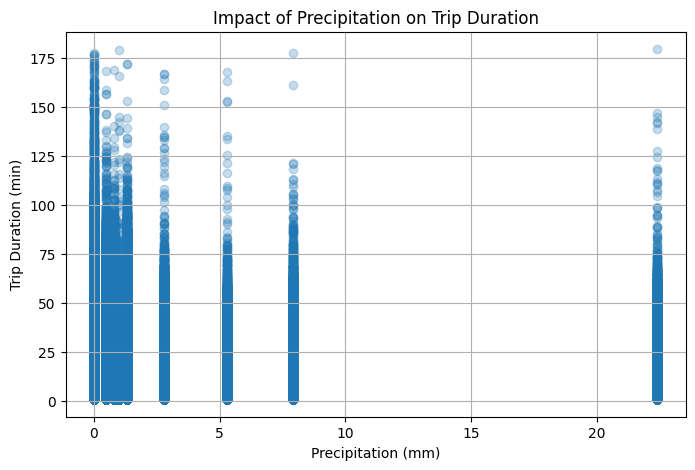

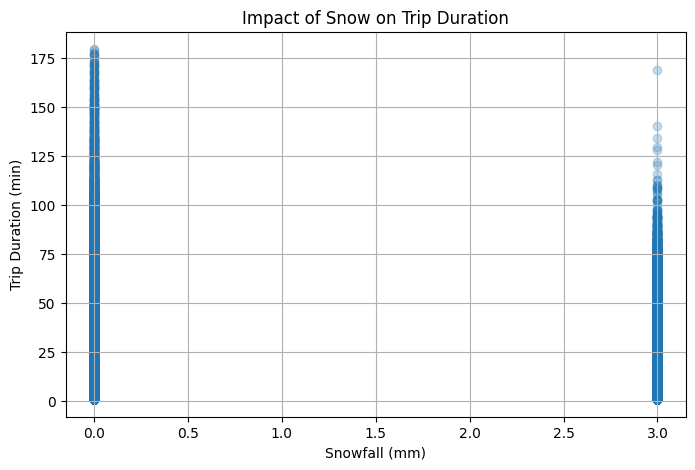

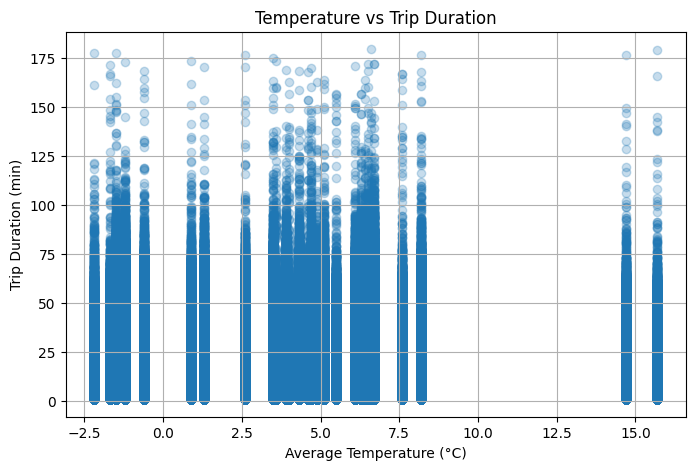

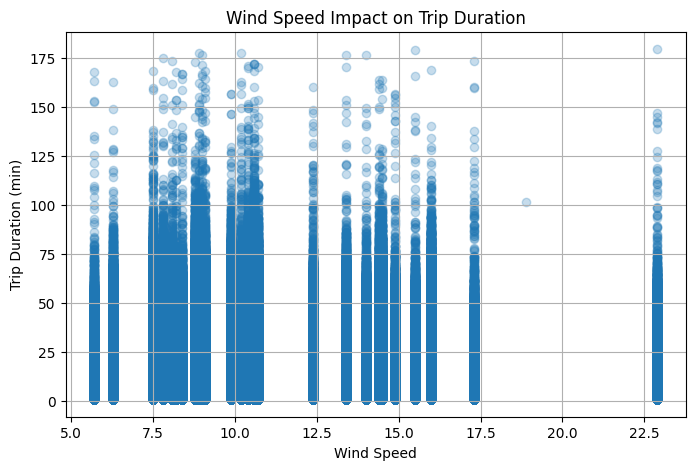

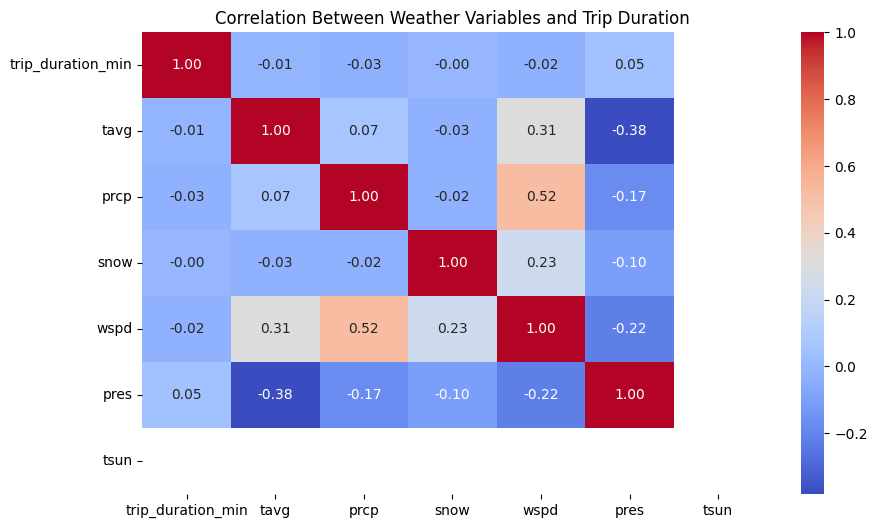

<Figure size 700x500 with 0 Axes>

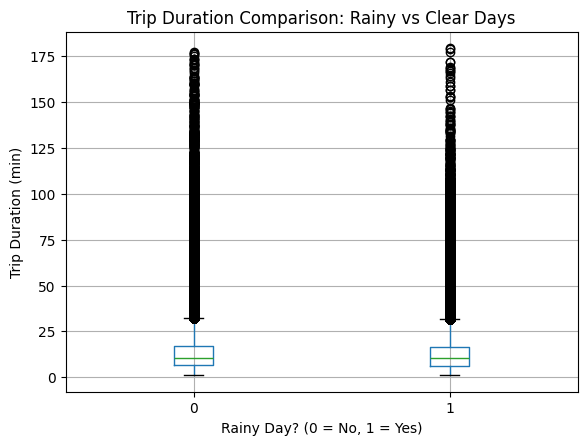

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. BASIC CLEANUP / FLAGS


# Make sure these columns exist in merged_df
required_cols = ["trip_duration_min", "prcp", "snow", "tavg", "wspd", "pres", "tsun"]
print("Columns present:", [c for c in required_cols if c in merged_df.columns])

# Fill NaNs in precip & snow with 0 (no rain/snow)
if "prcp" in merged_df.columns:
    merged_df["prcp"] = merged_df["prcp"].fillna(0)

if "snow" in merged_df.columns:
    merged_df["snow"] = merged_df["snow"].fillna(0)

# Interpolate other continuous weather features if they exist
for col in ["tavg", "wspd", "pres", "tsun"]:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].interpolate(method="linear")

# Create rainy flag (0 = no rain, 1 = rain)
if "prcp" in merged_df.columns:
    merged_df["rainy"] = (merged_df["prcp"] > 0).astype(int)

print(merged_df[["trip_duration_min", "prcp", "snow"]].head())

# Optional: cap trip_duration_min for nicer plots
merged_df_plot = merged_df.copy()
merged_df_plot = merged_df_plot[merged_df_plot["trip_duration_min"] <= 180]



# 2. SCATTER PLOTS


plt.figure(figsize=(8,5))
plt.scatter(merged_df_plot["prcp"], merged_df_plot["trip_duration_min"], alpha=0.25)
plt.title("Impact of Precipitation on Trip Duration")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Trip Duration (min)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(merged_df_plot["snow"], merged_df_plot["trip_duration_min"], alpha=0.25)
plt.title("Impact of Snow on Trip Duration")
plt.xlabel("Snowfall (mm)")
plt.ylabel("Trip Duration (min)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(merged_df_plot["tavg"], merged_df_plot["trip_duration_min"], alpha=0.25)
plt.title("Temperature vs Trip Duration")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Trip Duration (min)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(merged_df_plot["wspd"], merged_df_plot["trip_duration_min"], alpha=0.25)
plt.title("Wind Speed Impact on Trip Duration")
plt.xlabel("Wind Speed")
plt.ylabel("Trip Duration (min)")
plt.grid(True)
plt.show()
# 3. CORRELATION HEATMAP


heat_cols = ["trip_duration_min", "tavg", "prcp", "snow", "wspd", "pres", "tsun"]
heat_cols = [c for c in heat_cols if c in merged_df_plot.columns]  # keep only existing

corr = merged_df_plot[heat_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Weather Variables and Trip Duration")
plt.show()



# 4. RAINY vs CLEAR DAY BOXPLOT

if "rainy" in merged_df_plot.columns:
    plt.figure(figsize=(7,5))
    merged_df_plot.boxplot(column="trip_duration_min", by="rainy")
    plt.xlabel("Rainy Day? (0 = No, 1 = Yes)")
    plt.ylabel("Trip Duration (min)")
    plt.title("Trip Duration Comparison: Rainy vs Clear Days")
    plt.suptitle("")  # remove automatic super title
    plt.grid(True)
    plt.show()
else:
    print("Column 'rainy' not found – cannot draw rainy vs clear boxplot.")


✅ Loaded Linear from saved_models/Linear_RMSprop_lr1e-03.keras
✅ Loaded MLP from saved_models/MLP_RMSprop_lr1e-03.keras
✅ Loaded DNN from saved_models/DNN_RMSprop_lr1e-03.keras

Evaluating Linear...
Linear  ->  MSE: 17.9257,  MAE: 2.7365

Evaluating MLP...
MLP  ->  MSE: 0.5319,  MAE: 0.1650

Evaluating DNN...
DNN  ->  MSE: 0.2818,  MAE: 0.1414

Model comparison:


,model,mse,mae
0,Linear,17.925711,2.736495
1,MLP,0.531852,0.164965
2,DNN,0.281799,0.141377


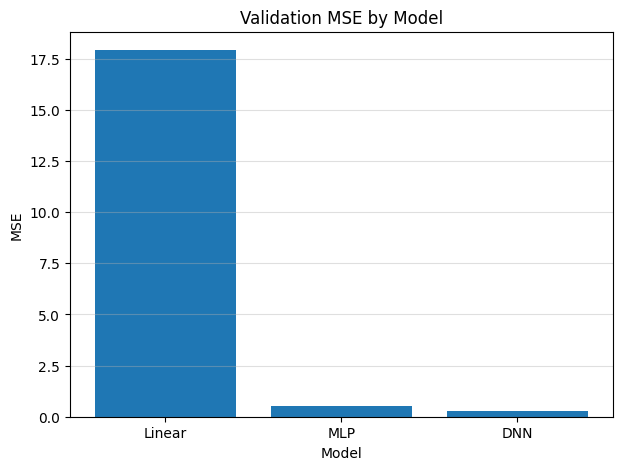

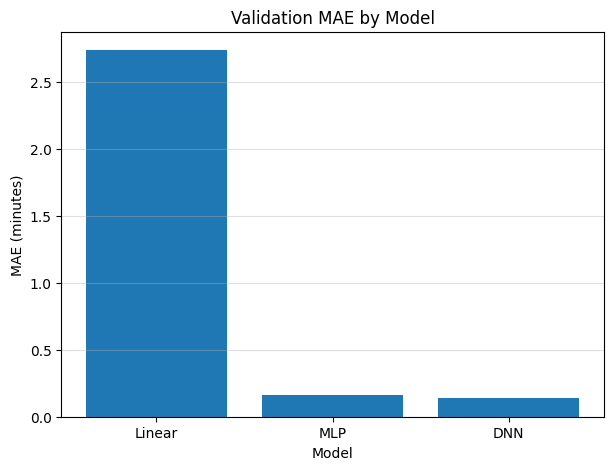

Using existing merged_df_sorted / train_size.

Mean absolute error by model and rain flag:


,model,rainy,mean_abs_err
0,Linear,0,2.690230
1,Linear,1,2.939911
2,MLP,0,0.169866
3,MLP,1,0.143417
4,DNN,0,0.144011
5,DNN,1,0.129798


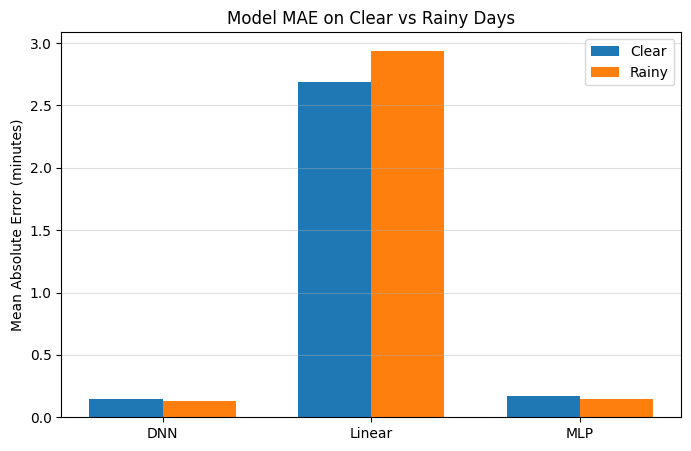

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. LOAD ALL THREE SAVED MODELS


model_paths = {
    "Linear": "saved_models/Linear_RMSprop_lr1e-03.keras",
    "MLP":    "saved_models/MLP_RMSprop_lr1e-03.keras",
    "DNN":    "saved_models/DNN_RMSprop_lr1e-03.keras",
}

models = {}
for name, path in model_paths.items():
    models[name] = load_model(path)
    print(f"✅ Loaded {name} from {path}")


# 2. EVALUATE MODELS → COLLECT MSE & MAE


results = []

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    mse, mae = model.evaluate(X_val_scaled, y_val, verbose=0)
    y_pred = model.predict(X_val_scaled, verbose=0).flatten()

    results.append({
        "model": name,
        "mse": mse,
        "mae": mae,
        "y_pred": y_pred,
    })
    print(f"{name}  ->  MSE: {mse:.4f},  MAE: {mae:.4f}")

# Put numeric metrics in a DataFrame (for bar charts)
metrics_df = pd.DataFrame(
    [{"model": r["model"], "mse": r["mse"], "mae": r["mae"]} for r in results]
)
print("\nModel comparison:")
display(metrics_df)


# 3. BAR CHARTS – MSE & MAE FOR ALL MODELS


plt.figure(figsize=(7,5))
plt.bar(metrics_df["model"], metrics_df["mse"])
plt.title("Validation MSE by Model")
plt.ylabel("MSE")
plt.xlabel("Model")
plt.grid(True, axis="y", alpha=0.4)
plt.show()

plt.figure(figsize=(7,5))
plt.bar(metrics_df["model"], metrics_df["mae"])
plt.title("Validation MAE by Model")
plt.ylabel("MAE (minutes)")
plt.xlabel("Model")
plt.grid(True, axis="y", alpha=0.4)
plt.show()


# 4. PREPARE VALIDATION DATAFRAME (ALIGN WITH X_val_scaled)


try:
    val_df = merged_df_sorted.iloc[train_size:].copy()
    print("Using existing merged_df_sorted / train_size.")
except NameError:
    print("Rebuilding sorted df and val_df...")
    merged_df_sorted = merged_df.sort_values("tpep_pickup_datetime").copy()
    X_sorted = merged_df_sorted[feature_cols].copy()
    y_sorted = merged_df_sorted["trip_duration_min"].copy()
    n = len(merged_df_sorted)
    train_size = int(0.8 * n)
    val_df = merged_df_sorted.iloc[train_size:].copy()

# Make sure prcp & rainy exist
if "prcp" in val_df.columns:
    val_df["prcp"] = val_df["prcp"].fillna(0)
    val_df["rainy"] = (val_df["prcp"] > 0).astype(int)
else:
    print("⚠️ 'prcp' not found in val_df – rainy/clear analysis will be skipped.")

# 5. ATTACH PREDICTIONS TO val_df FOR EACH MODEL
#    AND COMPUTE MAE ON RAINY vs CLEAR DAYS


rainy_mae_rows = []

for r in results:
    name = r["model"]
    y_pred = r["y_pred"]

    # Attach predictions to a copy of val_df
    tmp = val_df.copy()
    tmp["y_true"] = y_val  # assumes y_val is aligned with val_df order
    tmp["y_pred"] = y_pred
    tmp["abs_err"] = np.abs(tmp["y_true"] - tmp["y_pred"])

    if "rainy" in tmp.columns:
        grp = tmp.groupby("rainy")["abs_err"].mean()
        for rainy_flag in [0, 1]:
            if rainy_flag in grp.index:
                rainy_mae_rows.append({
                    "model": name,
                    "rainy": rainy_flag,
                    "mean_abs_err": grp.loc[rainy_flag]
                })

# If we were able to compute rainy vs clear MAE, plot it.
if len(rainy_mae_rows) > 0:
    rainy_df = pd.DataFrame(rainy_mae_rows)
    print("\nMean absolute error by model and rain flag:")
    display(rainy_df)

    # Pivot for bar plotting: index = model, columns = rainy (0/1)
    pivot = rainy_df.pivot(index="model", columns="rainy", values="mean_abs_err")
    # Ensure consistent column order 0 = clear, 1 = rainy
    pivot = pivot[[0, 1]].rename(columns={0: "Clear", 1: "Rainy"})

    # Grouped bar chart
    x = np.arange(len(pivot.index))  # models
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, pivot["Clear"], width, label="Clear")
    plt.bar(x + width/2, pivot["Rainy"], width, label="Rainy")

    plt.xticks(x, pivot.index)
    plt.ylabel("Mean Absolute Error (minutes)")
    plt.title("Model MAE on Clear vs Rainy Days")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.4)
    plt.show()
else:
    print("No rainy/clear MAE data available to plot.")


Columns present: ['trip_duration_min', 'prcp', 'snow', 'tavg', 'wspd', 'pres', 'tsun']
   trip_duration_min  prcp  snow
0           4.800000   0.0   0.0
1           7.416667   0.0   0.0
2           6.183333   0.0   0.0
3           4.850000   0.0   0.0
4          11.450000   0.0   0.0


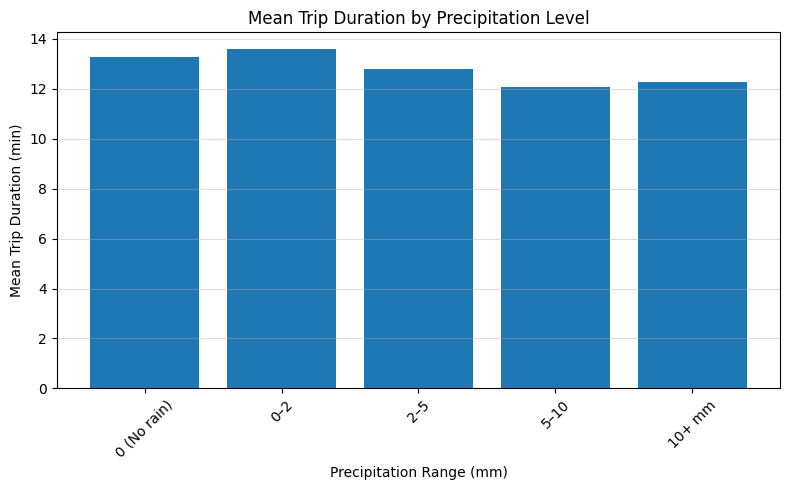

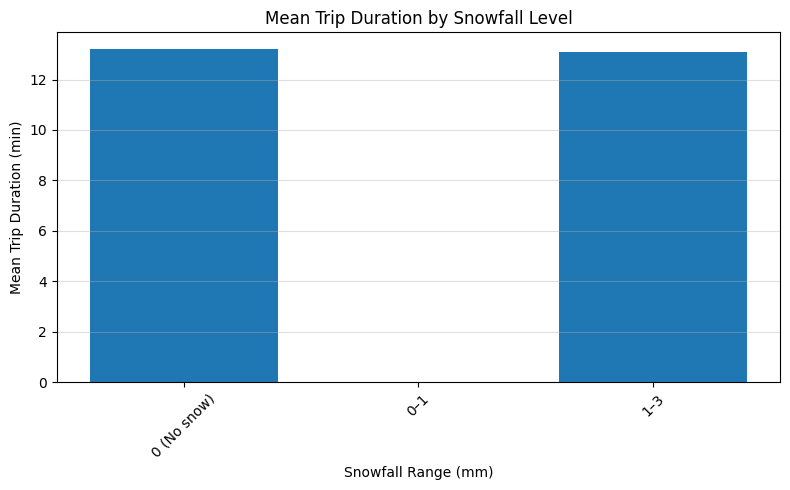

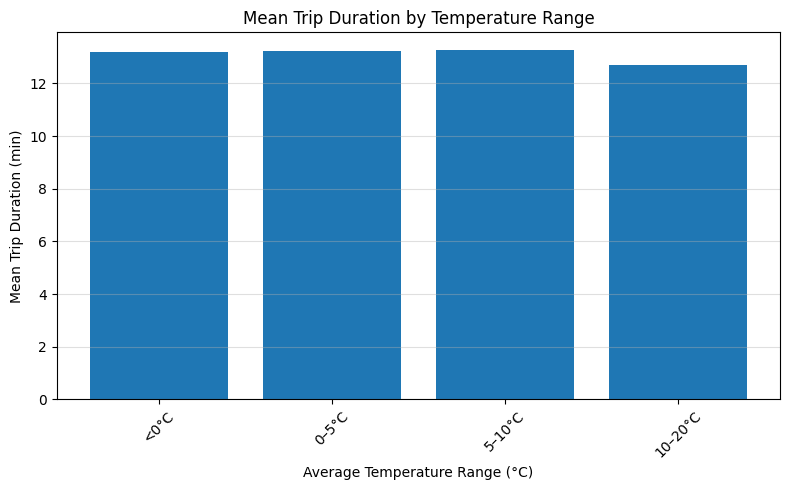

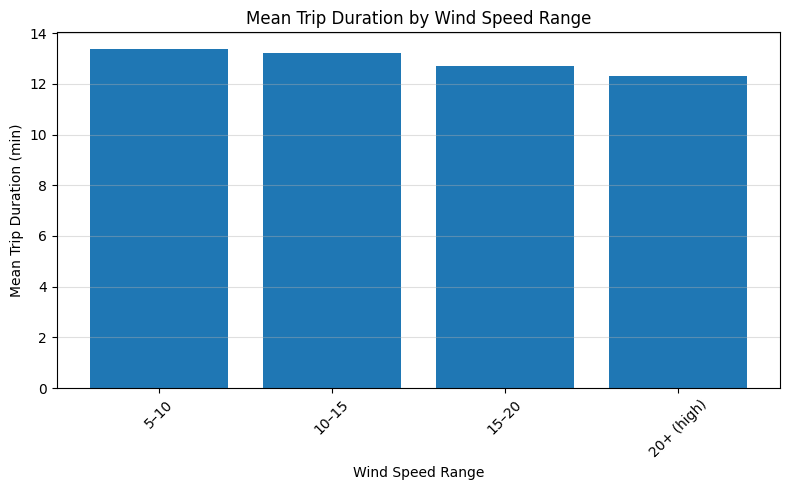

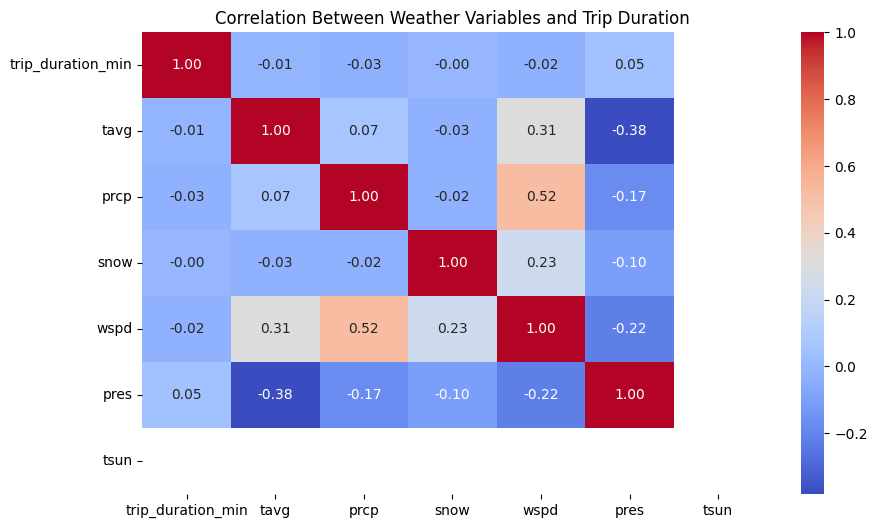

<Figure size 700x500 with 0 Axes>

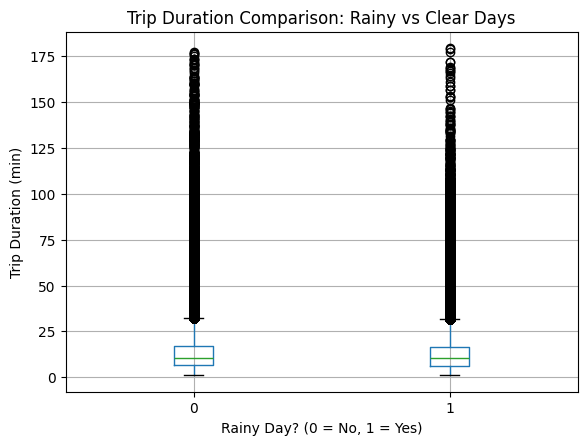

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



required_cols = ["trip_duration_min", "prcp", "snow", "tavg", "wspd", "pres", "tsun"]
print("Columns present:", [c for c in required_cols if c in merged_df.columns])

# Fill NaNs in precip & snow with 0 (no rain/snow)
if "prcp" in merged_df.columns:
    merged_df["prcp"] = merged_df["prcp"].fillna(0)

if "snow" in merged_df.columns:
    merged_df["snow"] = merged_df["snow"].fillna(0)

# Interpolate other continuous weather features if they exist
for col in ["tavg", "wspd", "pres", "tsun"]:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].interpolate(method="linear")

# Create rainy flag (0 = no rain, 1 = rain)
if "prcp" in merged_df.columns:
    merged_df["rainy"] = (merged_df["prcp"] > 0).astype(int)

print(merged_df[["trip_duration_min", "prcp", "snow"]].head())

# Optional: cap trip_duration_min for nicer plots
merged_df_plot = merged_df.copy()
merged_df_plot = merged_df_plot[merged_df_plot["trip_duration_min"] <= 180].copy()


# 2. AGGREGATED BAR CHARTS INSTEAD OF SCATTER PLOTS


# Helper to make nice bar chart from a binned series
def plot_binned_bar(df, value_col, bin_col, bins, labels, title, x_label):
    # Create bins
    df = df.copy()
    df[bin_col + "_bin"] = pd.cut(df[bin_col], bins=bins, labels=labels, include_lowest=True)
    grouped = df.groupby(bin_col + "_bin")[value_col].mean().reset_index()

    plt.figure(figsize=(8,5))
    plt.bar(grouped[bin_col + "_bin"].astype(str), grouped[value_col])
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel("Mean Trip Duration (min)")
    plt.xticks(rotation=45)
    plt.grid(True, axis="y", alpha=0.4)
    plt.tight_layout()
    plt.show()

# Precipitation vs mean trip duration
if "prcp" in merged_df_plot.columns:
    prcp_bins = [-0.01, 0, 2, 5, 10, 100]  # 0, light, moderate, heavy
    prcp_labels = ["0 (No rain)", "0–2", "2–5", "5–10", "10+ mm"]
    plot_binned_bar(
        merged_df_plot,
        value_col="trip_duration_min",
        bin_col="prcp",
        bins=prcp_bins,
        labels=prcp_labels,
        title="Mean Trip Duration by Precipitation Level",
        x_label="Precipitation Range (mm)"
    )

# Snow vs mean trip duration
if "snow" in merged_df_plot.columns:
    snow_bins = [-0.01, 0, 1, 3, 100]
    snow_labels = ["0 (No snow)", "0–1", "1–3", "3+ mm"]
    plot_binned_bar(
        merged_df_plot,
        value_col="trip_duration_min",
        bin_col="snow",
        bins=snow_bins,
        labels=snow_labels,
        title="Mean Trip Duration by Snowfall Level",
        x_label="Snowfall Range (mm)"
    )

# Temperature vs mean trip duration
if "tavg" in merged_df_plot.columns:
    # You can tweak these bins depending on temp range
    t_bins = [-50, 0, 5, 10, 20, 50]
    t_labels = ["<0°C", "0–5°C", "5–10°C", "10–20°C", "20°C+"]
    plot_binned_bar(
        merged_df_plot,
        value_col="trip_duration_min",
        bin_col="tavg",
        bins=t_bins,
        labels=t_labels,
        title="Mean Trip Duration by Temperature Range",
        x_label="Average Temperature Range (°C)"
    )

# Wind speed vs mean trip duration
if "wspd" in merged_df_plot.columns:
    w_bins = [0, 5, 10, 15, 20, 100]
    w_labels = ["0–5", "5–10", "10–15", "15–20", "20+ (high)"]
    plot_binned_bar(
        merged_df_plot,
        value_col="trip_duration_min",
        bin_col="wspd",
        bins=w_bins,
        labels=w_labels,
        title="Mean Trip Duration by Wind Speed Range",
        x_label="Wind Speed Range"
    )


# 3. CORRELATION HEATMAP (keep as-is)

heat_cols = ["trip_duration_min", "tavg", "prcp", "snow", "wspd", "pres", "tsun"]
heat_cols = [c for c in heat_cols if c in merged_df_plot.columns]

corr = merged_df_plot[heat_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Weather Variables and Trip Duration")
plt.show()


# 4. RAINY vs CLEAR DAY BOXPLOT (keep as-is)

if "rainy" in merged_df_plot.columns:
    plt.figure(figsize=(7,5))
    merged_df_plot.boxplot(column="trip_duration_min", by="rainy")
    plt.xlabel("Rainy Day? (0 = No, 1 = Yes)")
    plt.ylabel("Trip Duration (min)")
    plt.title("Trip Duration Comparison: Rainy vs Clear Days")
    plt.suptitle("")  # remove automatic super title
    plt.grid(True)
    plt.show()
else:
    print("Column 'rainy' not found – cannot draw rainy vs clear boxplot.")
